# Machine Learning - Kelompok 2

### Library
---

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

### Load Data and EDA
---

Combining 5 CSV into one single Dataframe

In [22]:
files = [
    'FINAL FOOD DATASET/FOOD-DATA-GROUP1.csv',
    'FINAL FOOD DATASET/FOOD-DATA-GROUP2.csv',
    'FINAL FOOD DATASET/FOOD-DATA-GROUP3.csv',
    'FINAL FOOD DATASET/FOOD-DATA-GROUP4.csv',
    'FINAL FOOD DATASET/FOOD-DATA-GROUP5.csv',
]

# Packed in Single Dataset
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Total initial rows loaded : {len(df)}")

Total initial rows loaded : 2395


In [23]:
columns_to_drop = ['Unnamed: 0', 'Unnamed: 0.1', 'id']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

Check the First 5 Row of the Dataset

In [24]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,0.9,0.0,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,7.8,0.0,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,0.8,0.1,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,1.5,0.0,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,1.2,0.0,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


In [25]:
print("Dtypes of the dataset:")
df.dtypes

Dtypes of the dataset:


food                        str
Caloric Value             int64
Fat                     float64
Saturated Fats          float64
Monounsaturated Fats    float64
Polyunsaturated Fats    float64
Carbohydrates           float64
Sugars                  float64
Protein                 float64
Dietary Fiber           float64
Cholesterol             float64
Sodium                  float64
Water                   float64
Vitamin A               float64
Vitamin B1              float64
Vitamin B11             float64
Vitamin B12             float64
Vitamin B2              float64
Vitamin B3              float64
Vitamin B5              float64
Vitamin B6              float64
Vitamin C               float64
Vitamin D               float64
Vitamin E               float64
Vitamin K               float64
Calcium                 float64
Copper                  float64
Iron                    float64
Magnesium               float64
Manganese               float64
Phosphorus              float64
Potassiu

Summary of Dataset

In [26]:
print("Statistic summary of the dataset :")
df.describe(include='all')

Statistic summary of the dataset :


,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
count,2395,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,...,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000
unique,2395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,cream cheese,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,223.769520,10.176276,3.924917,4.133622,2.152844,18.589021,4.457459,13.400777,2.235790,...,52.047728,9.581689,1.853271,34.429792,5.349964,156.236052,303.833939,52.258006,1.579192,106.929006
std,NaN,384.728244,29.008915,19.502262,12.939587,7.145738,29.406134,13.339929,32.294246,5.404483,...,115.933379,69.912400,5.155650,71.927990,21.005332,333.257099,589.507589,199.257203,4.937509,173.023891
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,44.500000,0.300000,0.064000,0.058000,0.071000,0.500000,0.000000,0.800000,0.000000,...,0.600000,0.040000,0.100000,1.500000,0.037000,0.800000,27.750000,0.016000,0.055000,16.876500
50%,NaN,117.000000,2.100000,0.500000,0.500000,0.400000,6.800000,0.086000,3.500000,0.200000,...,13.900000,0.100000,0.600000,10.400000,0.200000,42.300000,112.300000,0.053000,0.300000,53.840000
75%,NaN,258.000000,9.400000,2.700000,3.400000,1.700000,25.050000,3.200000,13.300000,2.200000,...,48.250000,0.400000,1.800000,36.950000,0.700000,171.350000,340.500000,0.090000,1.200000,135.074500


Handling Missing Value

In [27]:
print("Missing value of the dataset:")
df.isnull().sum()

Missing value of the dataset:


food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Vitamin B11             0
Vitamin B12             0
Vitamin B2              0
Vitamin B3              0
Vitamin B5              0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Copper                  0
Iron                    0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Nutrition Density       0
dtype: int64

Description : No Missing Value is being handled because missing value in this dataset is non-existence

---

Checking Feature Distribution using Histogram

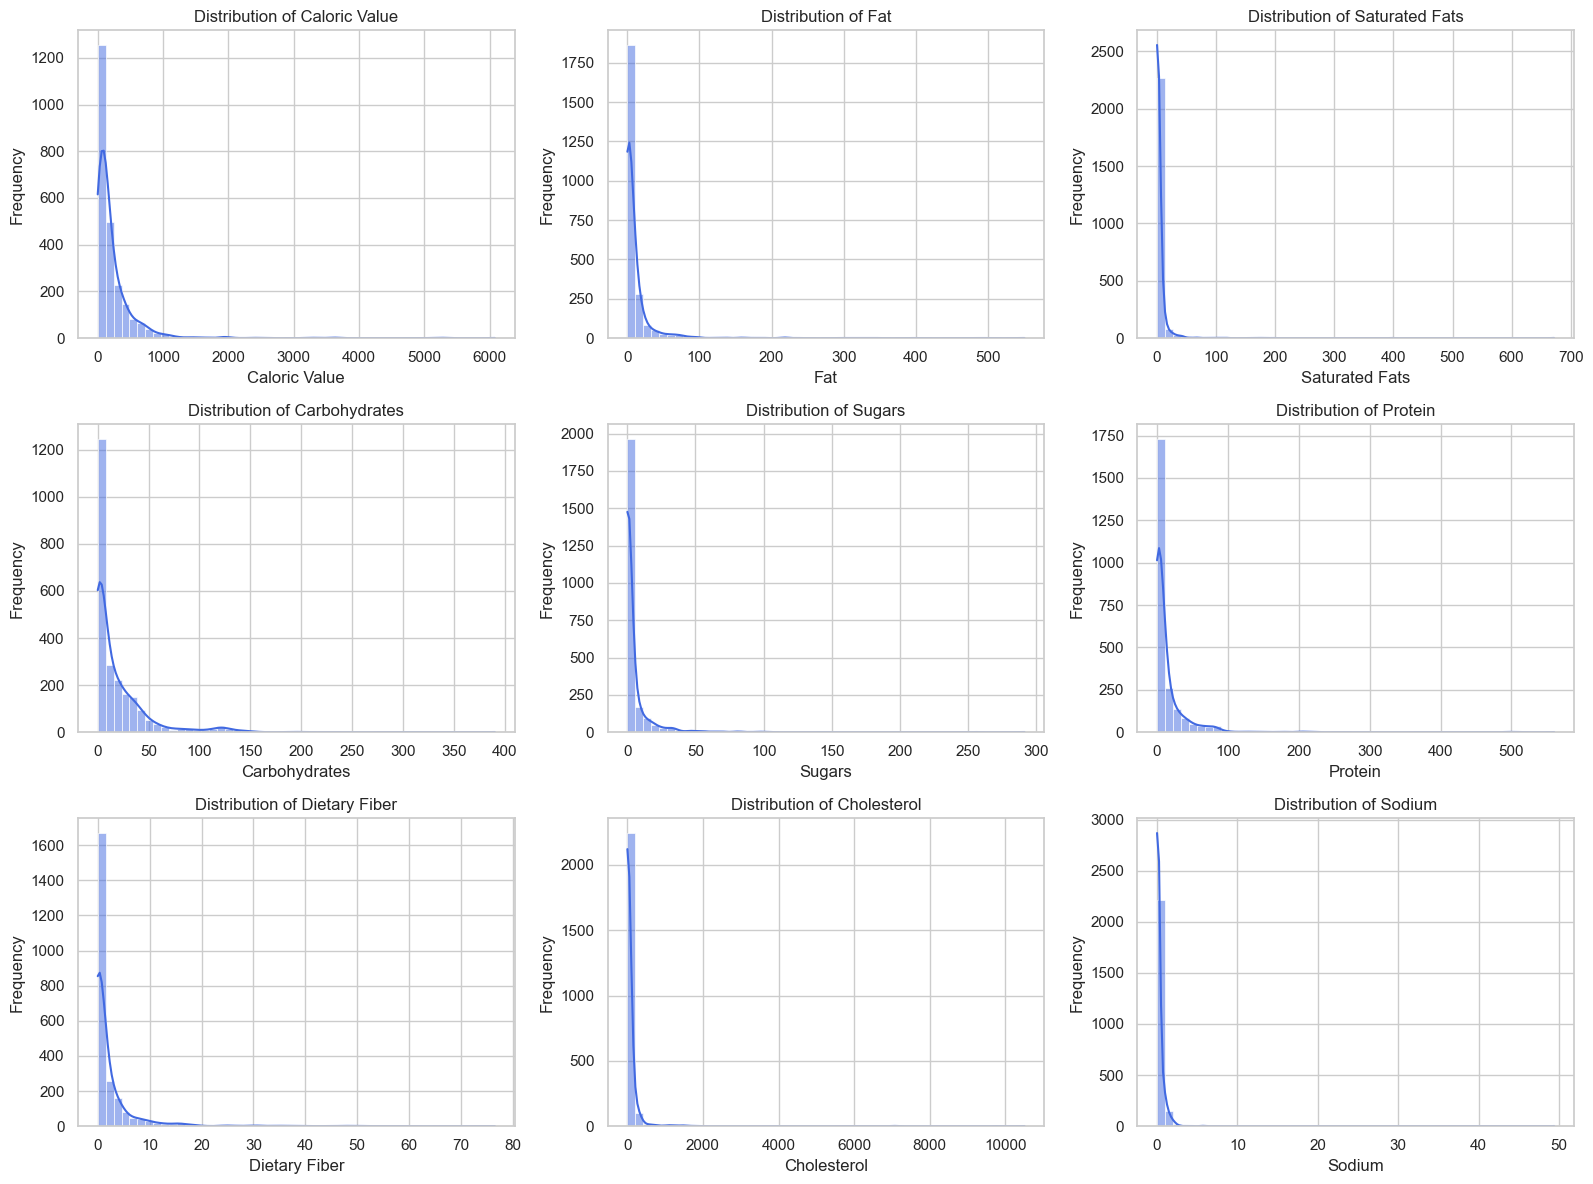

In [28]:
selected_cols = ['Caloric Value', 'Fat', 'Saturated Fats', 'Carbohydrates', 'Sugars', 'Protein', 'Dietary Fiber', 'Cholesterol', 'Sodium']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.histplot(df[col], kde=True, color='royalblue', ax=axes[i], bins = 50)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Description : Most feature is right-skewed. Most data is distributed on the lower side. The visualization is longer than it seems because there are outliers

---

Checking Outlier using Boxplot

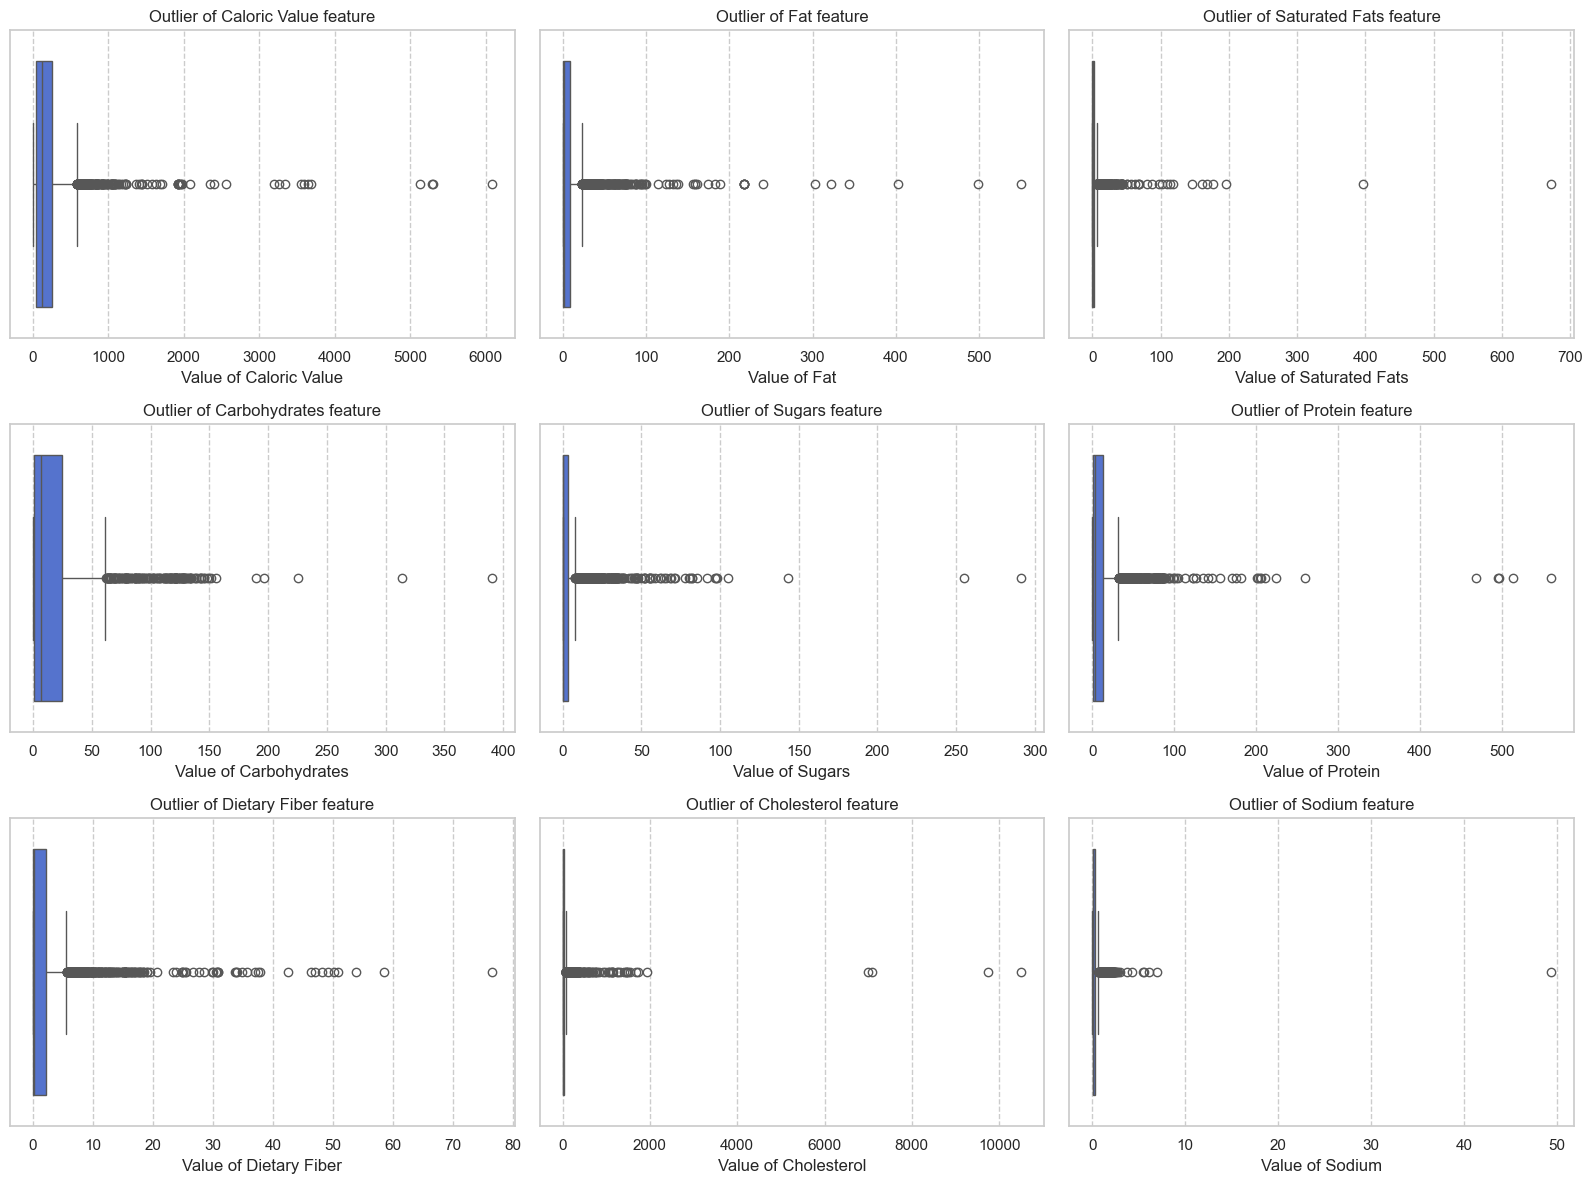

In [29]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.boxplot(x=df[col], color='royalblue', ax=axes[i])
    axes[i].set_title(f'Outlier of {col} feature')
    axes[i].set_xlabel(f'Value of {col}')
    axes[i].grid(axis='x', linestyle='--')

plt.tight_layout()
plt.show()

Description : all features have an outlier on it

---

Feature Correlation Mapping using Heatmap

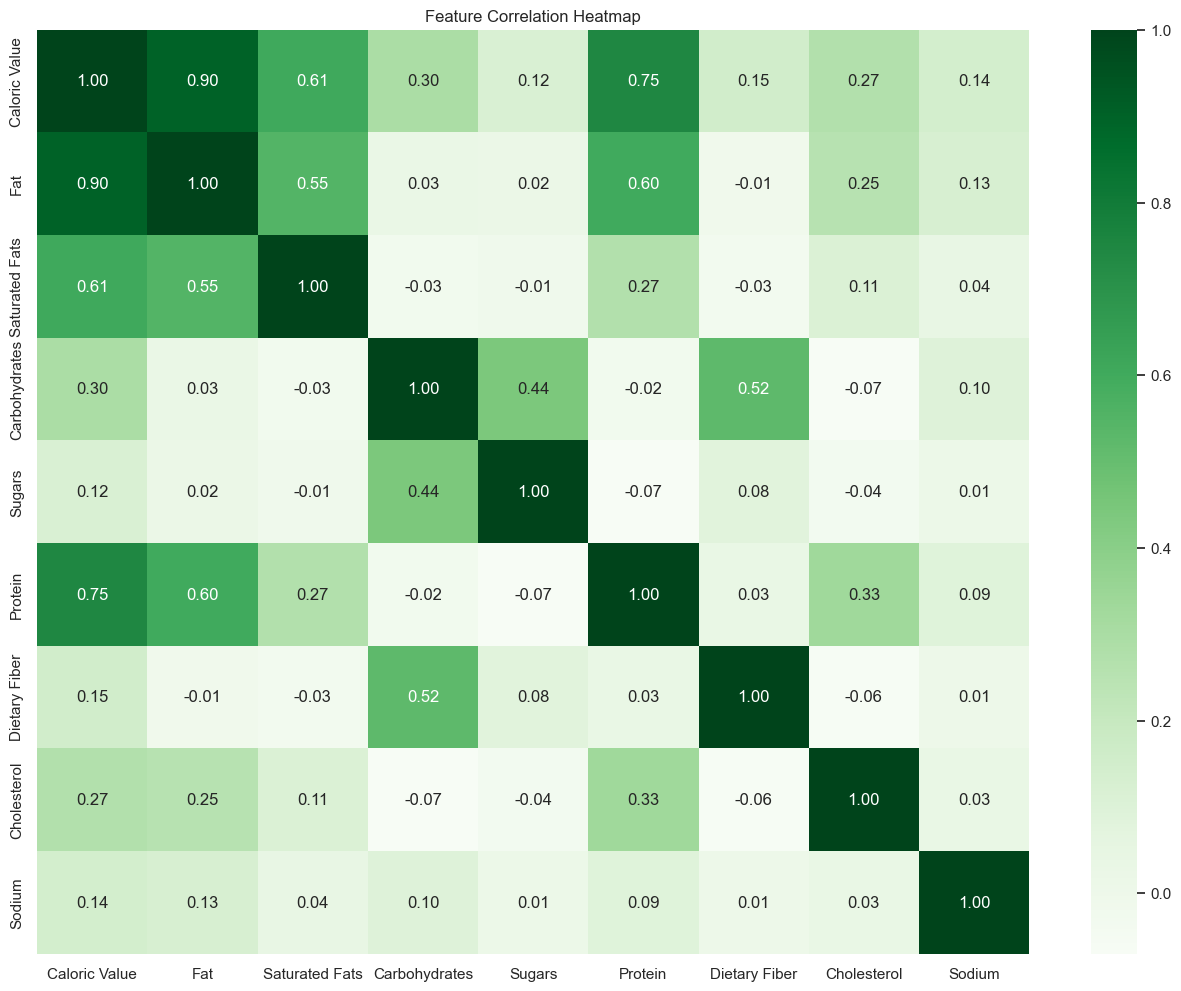

In [30]:
plt.figure(figsize=(16, 12))

corr_matrix = df[selected_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Greens')
plt.title('Feature Correlation Heatmap')
plt.show()

### Feature Engineering
---

Data Augmentation

In [31]:
print(f"Total Data Sebelum Augmentation : {len(df)}")

np.random.seed(42)
num_synthetic_samples = 200

synthetic_junk_food = pd.DataFrame({
    'Fat': np.random.uniform(36, 70, num_synthetic_samples),
    'Carbohydrates': np.random.uniform(80, 200, num_synthetic_samples),
    'Protein': np.random.uniform(10, 40, num_synthetic_samples),
    'Dietary Fiber': np.random.uniform(0, 3, num_synthetic_samples),
    'Sugars': np.random.uniform(41, 120, num_synthetic_samples),
    'Water': np.random.uniform(0, 10, num_synthetic_samples),
    'Caloric Value': np.random.uniform(801, 1500, num_synthetic_samples)
})

df = pd.concat([df, synthetic_junk_food], ignore_index=True)
print(f"Total Data Setelah Augmentation : {len(df)}")

Total Data Sebelum Augmentation : 2395
Total Data Setelah Augmentation : 2595


New Features

In [32]:
epsilon = 1e-5

df['Fat'] = df['Fat'].fillna(0).astype(np.float32)
df['Carbohydrates'] = df['Carbohydrates'].fillna(0).astype(np.float32)
df['Protein'] = df['Protein'].fillna(0).astype(np.float32)
df['Dietary Fiber'] = df['Dietary Fiber'].fillna(0).astype(np.float32)
df['Sugars'] = df['Sugars'].fillna(0).astype(np.float32)
df['Water'] = df['Water'].fillna(0).astype(np.float32)
df['Caloric Value'] = df['Caloric Value'].fillna(0).astype(np.float32)

estimated_weight = df['Fat'] + df['Carbohydrates'] + df['Protein'] + df['Water'] + epsilon
df['Calorie_Density'] = (df['Caloric Value'] / estimated_weight).astype(np.float32)

calculated_calories = (df['Fat'] * 9.0) + (df['Carbohydrates'] * 4.0) + (df['Protein'] * 4.0)
df['Calorie_Anomaly_Score'] = np.abs(df['Caloric Value'] - calculated_calories).astype(np.float32)

df['Sugar_to_Carb_Ratio'] = (df['Sugars'] / (df['Carbohydrates'] + epsilon)).astype(np.float32)
df['SatFat_to_TotalFat_Ratio'] = (df.get('Saturated Fats', 0).fillna(0) / (df['Fat'] + epsilon)).astype(np.float32)
df['Fiber_to_Carb_Ratio'] = (df['Dietary Fiber'] / (df['Carbohydrates'] + epsilon)).astype(np.float32)
df['Protein_to_Calorie_Ratio'] = (df['Protein'] / (df['Caloric Value'] + epsilon)).astype(np.float32)

conditions = [
    (df['Calorie_Anomaly_Score'] > 150) |
    (df['Caloric Value'] > 800) |
    (df['Sugars'] > 40) |
    (df['Fat'] > 35) |
    (df['Sugar_to_Carb_Ratio'] > 0.5) |
    (df['SatFat_to_TotalFat_Ratio'] > 0.4) |
    (df['Fiber_to_Carb_Ratio'] < 0.05) & (df['Carbohydrates'] > 30)
]
choices = [0]

df['Health_Class'] = np.select(conditions, choices, default=1)

print("(0 = Unhealthy, 1 = Healthy):")
print(df['Health_Class'].value_counts())

(0 = Unhealthy, 1 = Healthy):
Health_Class
1    1311
0    1284
Name: count, dtype: int64


Take 10 Feature (6 Input and 4 Hidden) - Set X and y

In [33]:
react_inputs = [
    'Fat', 'Carbohydrates', 'Protein', 'Dietary Fiber', 'Sugars', 'Water',
    'Sugar_to_Carb_Ratio', 'SatFat_to_TotalFat_Ratio', 'Fiber_to_Carb_Ratio', 'Protein_to_Calorie_Ratio'
]

X = df[react_inputs].copy().astype(np.float32)
y = df['Health_Class']

# Cleaning Infinite Number
X = X.replace([np.inf, -np.inf], 0).fillna(0)

### Train Test Split
---

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training matrix size : {X_train.shape[0]} samples")
print(f"Testing matrix size :  {X_test.shape[0]} samples")

Training matrix size : 2076 samples
Testing matrix size :  519 samples


### Modelling - Linear Regression and Random Forest
---

Scaling Pada Training

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Variable Accuracy, Precision, Recall, f-1 Score dan Confusion Matrix

In [36]:
classification_models = {
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
cms = {}
best_accuracy = -1
best_fitted_classifier = None

for name, model in classification_models.items():
    print(f"=== {name} ===")
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    
    print(f"Scores per Fold    : {cv_scores}")
    print(f"Mean CV Accuracy   : {cv_scores.mean():.4f}")
    print(f"Std Dev CV Accuracy: {cv_scores.std():.4f}")
    
    model.fit(X_train_scaled, y_train)
    
    preds = model.predict(X_test_scaled)
    
    test_acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    cms[name] = confusion_matrix(y_test, preds)
    

    results.append({
        'Model Name': name,
        'Mean CV Accuracy': cv_scores.mean(),
        'Test Accuracy': test_acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"Final Test Accuracy: {test_acc:.4f}")
    print(classification_report(y_test, preds, target_names=['Unhealthy (0)', 'Healthy (1)']))
    print("-" * 60)
    
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_fitted_classifier = model

# Ubah ke DataFrame agar bisa dianalisis
results_df = pd.DataFrame(results)

=== Random Forest Classifier ===
Scores per Fold    : [0.99278846 0.98554217 0.99036145 0.99277108 0.99518072]
Mean CV Accuracy   : 0.9913
Std Dev CV Accuracy: 0.0033
Final Test Accuracy: 0.9923
               precision    recall  f1-score   support

Unhealthy (0)       1.00      0.98      0.99       238
  Healthy (1)       0.99      1.00      0.99       281

     accuracy                           0.99       519
    macro avg       0.99      0.99      0.99       519
 weighted avg       0.99      0.99      0.99       519

------------------------------------------------------------
=== Gradient Boosting Classifier ===
Scores per Fold    : [0.97115385 0.97590361 0.98313253 0.99036145 0.97831325]
Mean CV Accuracy   : 0.9798
Std Dev CV Accuracy: 0.0066
Final Test Accuracy: 0.9769
               precision    recall  f1-score   support

Unhealthy (0)       0.99      0.96      0.97       238
  Healthy (1)       0.97      0.99      0.98       281

     accuracy                           0.98 

### Model Evaluation
---

Evaluation Metric for Cross Validation

   MEAN & STD DEV CROSS VALIDATION SCORES (5-FOLDS TRAINING SET)     

=== Random Forest Classifier ===
Precision : 0.9894 (standard deviation : 0.0036)
Recall    : 0.9932 (standard deviation : 0.0050)
F1-Score  : 0.9913 (standard deviation : 0.0033)
---------------------------------------------------------------------
=== Gradient Boosting Classifier ===
Precision : 0.9680 (standard deviation : 0.0129)
Recall    : 0.9922 (standard deviation : 0.0024)
F1-Score  : 0.9799 (standard deviation : 0.0064)
---------------------------------------------------------------------


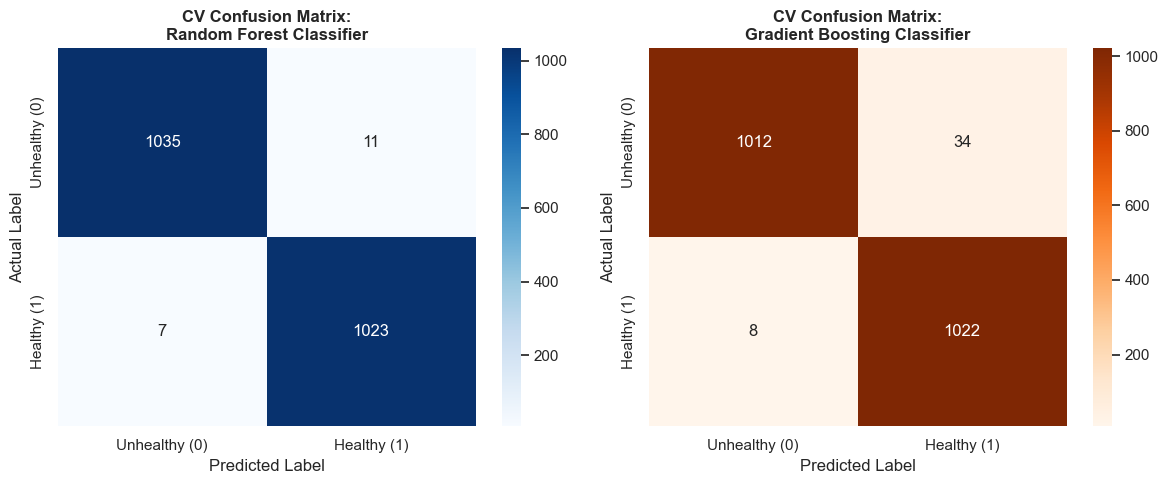

In [43]:
models_to_evaluate = {
    'Random Forest Classifier': classification_models['Random Forest Classifier'],
    'Gradient Boosting Classifier': classification_models['Gradient Boosting Classifier']
}

scoring_metrics = ['precision', 'recall', 'f1']
cv_cms = {}

print("=====================================================================")
print("   MEAN & STD DEV CROSS VALIDATION SCORES (5-FOLDS TRAINING SET)     ")
print("=====================================================================\n")

for name, model in models_to_evaluate.items():
    cv_results = cross_validate(model, X_train_scaled, y_train, cv=cv_strategy, scoring=scoring_metrics)
    
    print(f"=== {name} ===")
    print(f"Precision : {np.mean(cv_results['test_precision']):.4f} (standard deviation : {np.std(cv_results['test_precision']):.4f})")
    print(f"Recall    : {np.mean(cv_results['test_recall']):.4f} (standard deviation : {np.std(cv_results['test_recall']):.4f})")
    print(f"F1-Score  : {np.mean(cv_results['test_f1']):.4f} (standard deviation : {np.std(cv_results['test_f1']):.4f})")
    print("-" * 69)
    
    y_pred_cv = cross_val_predict(model, X_train_scaled, y_train, cv=cv_strategy)
    cv_cms[name] = confusion_matrix(y_train, y_pred_cv)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
colors = ['Blues', 'Oranges']

for i, (name, cm) in enumerate(cv_cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap=colors[i], 
                xticklabels=['Unhealthy (0)', 'Healthy (1)'], 
                yticklabels=['Unhealthy (0)', 'Healthy (1)'],
                ax=axes[i], cbar=True)
    axes[i].set_title(f'CV Confusion Matrix:\n{name}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xlabel('Predicted Label')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

Plotting Accuracy, Precision, Recall, f-1 Score

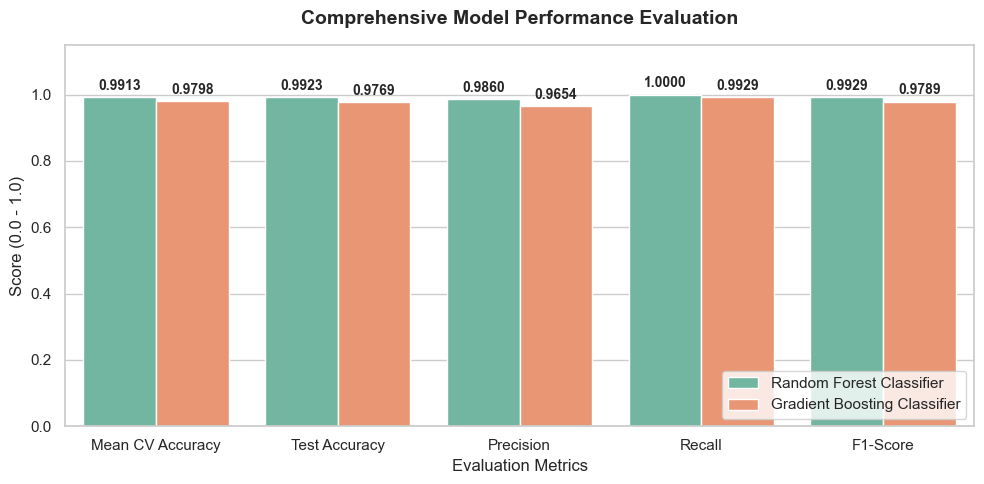

In [37]:
df_melted = results_df.melt(id_vars='Model Name', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Metric', y='Score', hue='Model Name', data=df_melted, palette='Set2')

plt.title('Comprehensive Model Performance Evaluation', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylim(0, 1.15)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')

plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

Plotting Confusion Matrix

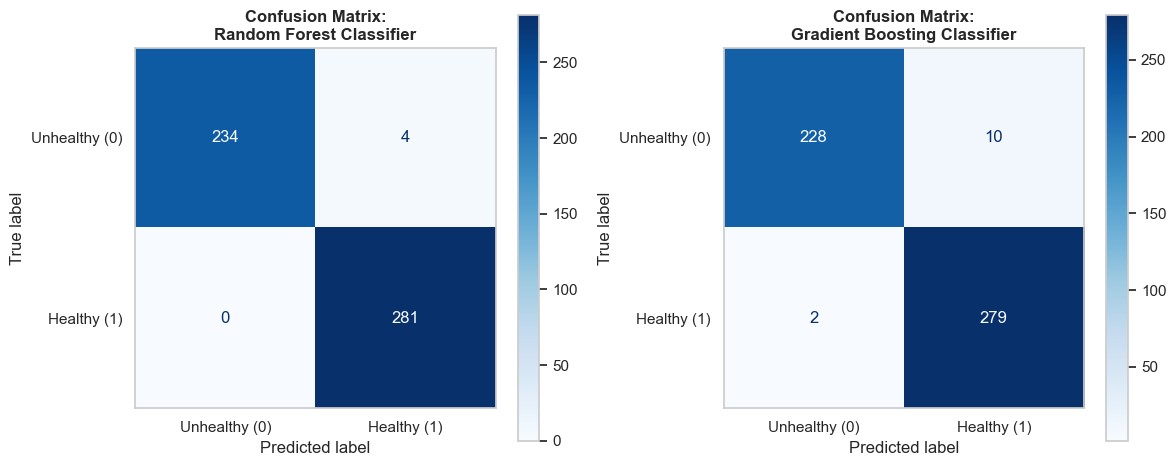

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

for i, (name, cm) in enumerate(cms.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unhealthy (0)', 'Healthy (1)'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Confusion Matrix:\n{name}', fontsize=12, fontweight='bold')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

### Export Model
---

In [40]:
if best_fitted_classifier is not None:
    classifier_pipeline = Pipeline([
        ('scaler', scaler),
        ('model', best_fitted_classifier)
    ])
  
    classifier_pipeline.fit(X_train, y_train)
    
    initial_type = [('float_input', FloatTensorType([None, 10]))]
    
    onnx_classifier = convert_sklearn(classifier_pipeline, initial_types=initial_type, target_opset=13)
    
    onnx_filename = "food_health_classifier_robust.onnx"
    try:
        with open(onnx_filename, "wb") as f:
            f.write(onnx_classifier.SerializeToString())
        print(f" ONNX Model : '{onnx_filename}'")
    except Exception as e:
        print(f"Failed : {e}")

 ONNX Model : 'food_health_classifier_robust.onnx'
